# 23. CatBoost Hyperparameter Tuning

**Цель:** подобрать оптимальные гиперпараметры CatBoost для продовой модели. Результаты используются для обновления `06_production/16_Production_Model_CatBoost.ipynb`.

**Связь с NB16:** Данные, split, фичи и бэктест — идентичны NB16 (champion cat_seq_new, prod_hold 25-70).

| Параметр | NB16 (baseline) | Исследуем |
|----------|-----------------|-----------|
| iterations | 300 | 200, 300, 500, 1000 |
| depth | 6 | 2, 3, 4, 6 |
| learning_rate | 0.05 | 0.01, 0.02, 0.03, 0.05 |
| l2_leaf_reg | default | 3, 5, 7 |
| min_data_in_leaf | default | 20, 50 |

**Метрика оптимизации:** `avg_%_per_trade` на test (prod_hold 25-70). AUC и net_% — дополнительно.

**Структура:** Setup → Data (как NB16) → Grid search → Анализ → Рекомендация для NB16

## 1. Импорты и константы

In [1]:
import sys, os, numpy as np, pandas as pd, itertools, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import catboost as cb

warnings.filterwarnings('ignore')

_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == '05_experiments' else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)

COMMISSION_RT = 0.001
THR_HI = 0.70
THR_LO = 0.25
SEQ_WINDOWS = [5, 15, 30, 60]
TARGET_COL = 'target'

print(f'Root: {_root}')

Root: c:\project\trading_bot_2Engine


## 2. Загрузка данных (идентично NB16)

Тот же labeled parquet, те же base features, rolling 5/15/30/60, split 7/1/2.

In [2]:
labeled_path = os.path.join(_root, 'outputs', 'data_labeled_tp_sl_1_05.parquet')
feat_path = os.path.join(_root, 'outputs', 'features_selected_tp_sl_1_05.txt')

df_raw = pd.read_parquet(labeled_path)
with open(feat_path, encoding='utf-8') as f:
    BASE_FEATURES = [l.strip() for l in f if l.strip()]
BASE_FEATURES = [c for c in BASE_FEATURES if c in df_raw.columns]

valid_full = df_raw.dropna(subset=BASE_FEATURES + [TARGET_COL]).copy()
valid_full = valid_full[valid_full[TARGET_COL].isin([-1.0, 0.0, 1.0])]
valid_full['date'] = pd.to_datetime(valid_full['datetime'], utc=True).dt.date
valid_full['ret_next'] = valid_full.groupby('session_key')['close_price'].pct_change().shift(-1)
valid_full = valid_full.dropna(subset=['ret_next'])

sort_col = 'datetime' if 'datetime' in valid_full.columns else 'timestamp'

KEY_FEATS = BASE_FEATURES[:10]
grp = valid_full.groupby('session_key', group_keys=False)
for w in SEQ_WINDOWS:
    for c in KEY_FEATS:
        if c in valid_full.columns:
            valid_full[f'{c}_roll{w}_mean'] = grp[c].transform(lambda x: x.rolling(w, min_periods=1).mean())
            valid_full[f'{c}_roll{w}_std'] = grp[c].transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))

SEQ_FEATURES = [f'{c}_roll{w}_{s}' for w in SEQ_WINDOWS for c in KEY_FEATS for s in ('mean', 'std')]
ALL_FEATURES = [c for c in (BASE_FEATURES + SEQ_FEATURES) if c in valid_full.columns]

dates = sorted(valid_full['date'].unique())
assert len(dates) >= 10, f'Нужно >= 10 дней, найдено {len(dates)}'

train_dates = set(dates[:7])
val_dates = set([dates[7]])
test_dates = set(dates[8:10])
val_day, test1_day, test2_day = dates[7], dates[8], dates[9]

valid = valid_full[valid_full[TARGET_COL].isin([-1.0, 1.0])].copy()
valid['y'] = (valid[TARGET_COL] == 1).astype(int)

train_df = valid[valid['date'].isin(train_dates)].sort_values(['session_key', sort_col]).reset_index(drop=True)
val_df = valid[valid['date'].isin(val_dates)].sort_values(['session_key', sort_col]).reset_index(drop=True)
test_df = valid[valid['date'].isin(test_dates)].sort_values(['session_key', sort_col]).reset_index(drop=True)

val_df_full = valid_full[valid_full['date'] == val_day].dropna(subset=ALL_FEATURES).sort_values(['session_key', sort_col]).reset_index(drop=True)
test1_df_full = valid_full[valid_full['date'] == test1_day].dropna(subset=ALL_FEATURES).sort_values(['session_key', sort_col]).reset_index(drop=True)
test2_df_full = valid_full[valid_full['date'] == test2_day].dropna(subset=ALL_FEATURES).sort_values(['session_key', sort_col]).reset_index(drop=True)
test_df_full = valid_full[valid_full['date'].isin(test_dates)].dropna(subset=ALL_FEATURES).sort_values(['session_key', sort_col]).reset_index(drop=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[ALL_FEATURES].fillna(0))
X_val = scaler.transform(val_df[ALL_FEATURES].fillna(0))
X_test = scaler.transform(test_df[ALL_FEATURES].fillna(0))
X_val_full = scaler.transform(val_df_full[ALL_FEATURES].fillna(0))
X_test1_full = scaler.transform(test1_df_full[ALL_FEATURES].fillna(0))
X_test2_full = scaler.transform(test2_df_full[ALL_FEATURES].fillna(0))
X_test_full = scaler.transform(test_df_full[ALL_FEATURES].fillna(0))

y_train = train_df['y'].values
y_val = val_df['y'].values
y_test = test_df['y'].values

print(f'Dates: train={min(train_dates)}..{max(train_dates)} | val={val_day} | test={test1_day}, {test2_day}')
print(f'Rows: train={len(train_df):,} val={len(val_df):,} test={len(test_df):,}')
print(f'Full (backtest): val={len(val_df_full):,} test1={len(test1_df_full):,} test2={len(test2_df_full):,} test_total={len(test_df_full):,}')
print(f'Features: {len(ALL_FEATURES)}')

Dates: train=2026-02-01..2026-02-07 | val=2026-02-08 | test=2026-02-09, 2026-02-10
Rows: train=123,971 val=23,108 test=39,475
Full (backtest): val=45,592 test1=48,073 test2=26,364 test_total=74,437
Features: 101


## 3. Бэктест prod_hold 25-70 (как в NB16)

In [3]:
def backtest_prod_hold_asym(proba, ret, session_ids, thr_hi=THR_HI, thr_lo=THR_LO, commission_rt=COMMISSION_RT):
    pred = np.where(proba >= thr_hi, 1, np.where(proba <= thr_lo, 0, -1))
    n = len(proba)
    pos = np.zeros(n, dtype=np.float64)
    prev = 0.0
    for i in range(n):
        if session_ids is not None and i > 0 and session_ids[i] != session_ids[i - 1]:
            prev = 0.0
        if pred[i] == 1: pos[i], prev = 1.0, 1.0
        elif pred[i] == 0: pos[i], prev = -1.0, -1.0
        else: pos[i] = prev
    pos_prev = np.roll(pos, 1); pos_prev[0] = 0.0
    sess_chg = np.zeros(n, dtype=bool)
    if session_ids is not None:
        sess_chg[1:] = session_ids[1:] != session_ids[:-1]
    pos_prev = np.where(sess_chg, 0.0, pos_prev)
    pos_changed = (pos != pos_prev) & ((pos != 0) | (pos_prev != 0))
    is_flip = pos_changed & (pos != 0) & (pos_prev != 0) & (pos * pos_prev < 0)
    fee_total = np.where(pos_changed, np.where(is_flip, commission_rt, commission_rt / 2.0), 0.0).sum()
    pnl_net = (pos * ret).sum() - fee_total
    trades = int(pos_changed.sum())
    avg_trade = float((pnl_net * 100) / trades) if trades > 0 else np.nan
    return {'trades': trades, 'net_%': float(pnl_net * 100), 'avg_%_per_trade': avg_trade}

print('backtest_prod_hold_asym ready')

backtest_prod_hold_asym ready


## 4. Grid Search — этап 1: iterations, depth, learning_rate

**depth** — максимальная глубина дерева (число уровней от корня до листа). Меньше depth = проще модель, меньше переобучение. Малый lr + малый depth часто даёт устойчивые вероятности.

Базовый поиск. Добавлены depth=2,3 и lr=0.01,0.02 — зона «shallow + slow» (200/6/0.03 дала лучший avg/trade). Оцениваем по **avg_%_per_trade** на test.

In [4]:
PARAM_GRID_1 = {
    'iterations': [200, 300, 500, 1000],
    'depth': [2, 3, 4, 6],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
}

keys = list(PARAM_GRID_1.keys())
vals = list(PARAM_GRID_1.values())
combos = list(itertools.product(*vals))

results_1 = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    m = cb.CatBoostClassifier(
        iterations=params['iterations'],
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        random_seed=42,
        verbose=0,
    )
    m.fit(X_train, y_train)
    p_val = m.predict_proba(X_val)[:, 1]
    p_test = m.predict_proba(X_test)[:, 1]
    p_test_full = m.predict_proba(X_test_full)[:, 1]
    auc_val = roc_auc_score(y_val, p_val)
    auc_test = roc_auc_score(y_test, p_test)
    bt = backtest_prod_hold_asym(p_test_full, test_df_full['ret_next'].values, test_df_full['session_key'].values)
    results_1.append({
        **params,
        'auc_val': auc_val,
        'auc_test': auc_test,
        'net_%': bt['net_%'],
        'trades': bt['trades'],
        'avg_%_per_trade': bt['avg_%_per_trade'],
    })
    print(f"{i+1}/{len(combos)} iter={params['iterations']} d={params['depth']} lr={params['learning_rate']} -> avg/trade={bt['avg_%_per_trade']:.4f}%")

df1 = pd.DataFrame(results_1)
df1 = df1.sort_values('avg_%_per_trade', ascending=False).reset_index(drop=True)
print('\n=== Топ-10 по avg_%_per_trade (test) ===')
print(df1.head(10).to_string(index=False))

1/64 iter=200 d=2 lr=0.01 -> avg/trade=nan%
2/64 iter=200 d=2 lr=0.02 -> avg/trade=nan%
3/64 iter=200 d=2 lr=0.03 -> avg/trade=-0.6338%
4/64 iter=200 d=2 lr=0.05 -> avg/trade=1.6343%
5/64 iter=200 d=3 lr=0.01 -> avg/trade=nan%
6/64 iter=200 d=3 lr=0.02 -> avg/trade=0.6490%
7/64 iter=200 d=3 lr=0.03 -> avg/trade=2.7680%
8/64 iter=200 d=3 lr=0.05 -> avg/trade=2.8087%
9/64 iter=200 d=4 lr=0.01 -> avg/trade=nan%
10/64 iter=200 d=4 lr=0.02 -> avg/trade=3.6540%
11/64 iter=200 d=4 lr=0.03 -> avg/trade=2.6921%
12/64 iter=200 d=4 lr=0.05 -> avg/trade=2.7070%
13/64 iter=200 d=6 lr=0.01 -> avg/trade=3.6470%
14/64 iter=200 d=6 lr=0.02 -> avg/trade=2.8030%
15/64 iter=200 d=6 lr=0.03 -> avg/trade=2.8293%
16/64 iter=200 d=6 lr=0.05 -> avg/trade=2.4544%
17/64 iter=300 d=2 lr=0.01 -> avg/trade=nan%
18/64 iter=300 d=2 lr=0.02 -> avg/trade=-0.4254%
19/64 iter=300 d=2 lr=0.03 -> avg/trade=2.2377%
20/64 iter=300 d=2 lr=0.05 -> avg/trade=2.6715%
21/64 iter=300 d=3 lr=0.01 -> avg/trade=nan%
22/64 iter=300 d=

## 5. Этап 2: l2_leaf_reg, min_data_in_leaf (вокруг лучших из этапа 1)

Берём топ-3 конфигурации по avg/trade и пробуем регуляризацию.

In [5]:
best_base = df1.iloc[0]
best_iter = int(best_base['iterations'])
best_depth = int(best_base['depth'])
best_lr = float(best_base['learning_rate'])

PARAM_GRID_2 = {
    'l2_leaf_reg': [3, 5, 7],
    'min_data_in_leaf': [20, 50],
}

keys2 = list(PARAM_GRID_2.keys())
vals2 = list(PARAM_GRID_2.values())
combos2 = list(itertools.product(*vals2))

results_2 = []
for i, combo in enumerate(combos2):
    p2 = dict(zip(keys2, combo))
    m = cb.CatBoostClassifier(
        iterations=best_iter,
        depth=best_depth,
        learning_rate=best_lr,
        l2_leaf_reg=p2['l2_leaf_reg'],
        min_data_in_leaf=p2['min_data_in_leaf'],
        random_seed=42,
        verbose=0,
    )
    m.fit(X_train, y_train)
    p_test_full = m.predict_proba(X_test_full)[:, 1]
    auc_test = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    bt = backtest_prod_hold_asym(p_test_full, test_df_full['ret_next'].values, test_df_full['session_key'].values)
    results_2.append({
        'iterations': best_iter,
        'depth': best_depth,
        'learning_rate': best_lr,
        **p2,
        'auc_test': auc_test,
        'net_%': bt['net_%'],
        'trades': bt['trades'],
        'avg_%_per_trade': bt['avg_%_per_trade'],
    })
    print(f"{i+1}/{len(combos2)} l2={p2['l2_leaf_reg']} min_leaf={p2['min_data_in_leaf']} -> avg/trade={bt['avg_%_per_trade']:.4f}%")

df2 = pd.DataFrame(results_2)
df2 = df2.sort_values('avg_%_per_trade', ascending=False).reset_index(drop=True)
print('\n=== Топ по avg_%_per_trade с регуляризацией ===')
print(df2.head(20).to_string(index=False))

1/6 l2=3 min_leaf=20 -> avg/trade=3.9259%
2/6 l2=3 min_leaf=50 -> avg/trade=3.9259%
3/6 l2=5 min_leaf=20 -> avg/trade=3.9259%
4/6 l2=5 min_leaf=50 -> avg/trade=3.9259%
5/6 l2=7 min_leaf=20 -> avg/trade=3.3767%
6/6 l2=7 min_leaf=50 -> avg/trade=3.3767%

=== Топ по avg_%_per_trade с регуляризацией ===
 iterations  depth  learning_rate  l2_leaf_reg  min_data_in_leaf  auc_test     net_%  trades  avg_%_per_trade
        300      4           0.01            3                20  0.687211 35.333120       9         3.925902
        300      4           0.01            3                50  0.687211 35.333120       9         3.925902
        300      4           0.01            5                20  0.687037 35.333120       9         3.925902
        300      4           0.01            5                50  0.687037 35.333120       9         3.925902
        300      4           0.01            7                20  0.689159 27.013479       8         3.376685
        300      4           0.01      

## 6. Сравнение: NB16 baseline vs лучший конфиг (с разбивкой по дням)

Бэктест по дням: val, test1, test2 — чтобы проверить устойчивость преимущества.

In [16]:
def run_backtest_by_day(model, X_val_f, X_t1_f, X_t2_f, val_df, t1_df, t2_df):
    """Бэктест по дням: val, test1, test2."""
    p_val = model.predict_proba(X_val_f)[:, 1]
    p_t1 = model.predict_proba(X_t1_f)[:, 1]
    p_t2 = model.predict_proba(X_t2_f)[:, 1]
    bt_val = backtest_prod_hold_asym(p_val, val_df['ret_next'].values, val_df['session_key'].values)
    bt_t1 = backtest_prod_hold_asym(p_t1, t1_df['ret_next'].values, t1_df['session_key'].values)
    bt_t2 = backtest_prod_hold_asym(p_t2, t2_df['ret_next'].values, t2_df['session_key'].values)
    return {'val': bt_val, 'test1': bt_t1, 'test2': bt_t2}

NB16_BASELINE = {'iterations': 300, 'depth': 6, 'learning_rate': 0.05}

m_baseline = cb.CatBoostClassifier(**NB16_BASELINE, random_seed=42, verbose=0)
m_baseline.fit(X_train, y_train)
bt_bl_by_day = run_backtest_by_day(m_baseline, X_val_full, X_test1_full, X_test2_full,
                                   val_df_full, test1_df_full, test2_df_full)
p_test_bl = m_baseline.predict_proba(X_test_full)[:, 1]
bt_baseline = backtest_prod_hold_asym(p_test_bl, test_df_full['ret_next'].values, test_df_full['session_key'].values)

best_final = df2.iloc[0] if len(df2) > 0 else df1.iloc[0]
best_params = {
    'iterations': int(best_final['iterations']),
    'depth': int(best_final['depth']),
    'learning_rate': float(best_final['learning_rate']),
}
if 'l2_leaf_reg' in best_final:
    best_params['l2_leaf_reg'] = int(best_final['l2_leaf_reg'])
if 'min_data_in_leaf' in best_final:
    best_params['min_data_in_leaf'] = int(best_final['min_data_in_leaf'])

m_best = cb.CatBoostClassifier(**best_params, random_seed=42, verbose=0)
m_best.fit(X_train, y_train)
bt_best_by_day = run_backtest_by_day(m_best, X_val_full, X_test1_full, X_test2_full,
                                     val_df_full, test1_df_full, test2_df_full)
p_test_best = m_best.predict_proba(X_test_full)[:, 1]
bt_best = backtest_prod_hold_asym(p_test_best, test_df_full['ret_next'].values, test_df_full['session_key'].values)

# 200/6/0.05 — кандидат: много сделок + выше avg/trade
CANDIDATE_200_6 = {'iterations': 200, 'depth': 6, 'learning_rate': 0.05}
m_cand = cb.CatBoostClassifier(**CANDIDATE_200_6, random_seed=42, verbose=0)
m_cand.fit(X_train, y_train)
bt_cand_by_day = run_backtest_by_day(m_cand, X_val_full, X_test1_full, X_test2_full,
                                     val_df_full, test1_df_full, test2_df_full)
bt_cand = backtest_prod_hold_asym(m_cand.predict_proba(X_test_full)[:, 1],
                                  test_df_full['ret_next'].values, test_df_full['session_key'].values)

# 1000/4/0.02 — кандидат: более точная сходимость, 587 сделок, avg 2.28%
CANDIDATE_1000_4 = {'iterations': 1000, 'depth': 4, 'learning_rate': 0.02}
m_cand2 = cb.CatBoostClassifier(**CANDIDATE_1000_4, random_seed=42, verbose=0)
m_cand2.fit(X_train, y_train)
bt_cand2_by_day = run_backtest_by_day(m_cand2, X_val_full, X_test1_full, X_test2_full,
                                      val_df_full, test1_df_full, test2_df_full)
bt_cand2 = backtest_prod_hold_asym(m_cand2.predict_proba(X_test_full)[:, 1],
                                   test_df_full['ret_next'].values, test_df_full['session_key'].values)

# Таблица по дням
rows = []
for name, by_day, total in [('NB16 prod', bt_bl_by_day, bt_baseline), ('200/6/0.05', bt_cand_by_day, bt_cand),
                            ('1000/4/0.02', bt_cand2_by_day, bt_cand2), ('NB23 best', bt_best_by_day, bt_best)]:
    for day, lbl in [('val', f'{val_day}'), ('test1', f'{test1_day}'), ('test2', f'{test2_day}')]:
        b = by_day[day]
        rows.append({'config': name, 'day': day, 'date': lbl, 'net_%': b['net_%'], 'trades': b['trades'],
                     'avg_%_per_trade': b['avg_%_per_trade']})
    rows.append({'config': name, 'day': 'test_total', 'date': 'test1+2', 'net_%': total['net_%'],
                 'trades': total['trades'], 'avg_%_per_trade': total['avg_%_per_trade']})

df_days = pd.DataFrame(rows)
day_order = ['val', 'test1', 'test2', 'test_total']
piv_avg = df_days.pivot_table(index='config', columns='day', values='avg_%_per_trade', aggfunc='first').reindex(columns=day_order)
piv_net = df_days.pivot_table(index='config', columns='day', values='net_%', aggfunc='first').reindex(columns=day_order)
piv_trades = df_days.pivot_table(index='config', columns='day', values='trades', aggfunc='first').reindex(columns=day_order)

print('=== Разбивка по дням: avg_%_per_trade ===')
print(piv_avg.to_string())
print()
print('=== Разбивка по дням: net_% ===')
print(piv_net.to_string())
print()
print('=== Разбивка по дням: trades ===')
print(piv_trades.to_string())
print()
print('=== Сводка test_total ===')
print(f'NB16 baseline:  net_%={bt_baseline["net_%"]:.2f}%  trades={bt_baseline["trades"]}  avg/trade={bt_baseline["avg_%_per_trade"]:.4f}%')
print(f'200/6/0.05:    net_%={bt_cand["net_%"]:.2f}%  trades={bt_cand["trades"]}  avg/trade={bt_cand["avg_%_per_trade"]:.4f}%')
print(f'1000/4/0.02:   net_%={bt_cand2["net_%"]:.2f}%  trades={bt_cand2["trades"]}  avg/trade={bt_cand2["avg_%_per_trade"]:.4f}%')
print(f'NB23 best:     net_%={bt_best["net_%"]:.2f}%  trades={bt_best["trades"]}  avg/trade={bt_best["avg_%_per_trade"]:.4f}%')
print(f'\n200/6/0.05 vs NB16:  avg {bt_cand["avg_%_per_trade"]-bt_baseline["avg_%_per_trade"]:+.4f}%, net_% {bt_cand["net_%"]-bt_baseline["net_%"]:+.2f}%')
print(f'1000/4/0.02 vs NB16: avg {bt_cand2["avg_%_per_trade"]-bt_baseline["avg_%_per_trade"]:+.4f}%, net_% {bt_cand2["net_%"]-bt_baseline["net_%"]:+.2f}%')

=== Разбивка по дням: avg_%_per_trade ===
day               val     test1     test2  test_total
config                                               
1000/4/0.02  1.835827  2.320379  2.000491    2.281869
200/6/0.05   1.452256  2.429882  2.317285    2.454377
NB16 prod    1.780247  2.022062  1.568090    1.921349
NB23 best    0.923195  2.555964  6.665778    3.925902

=== Разбивка по дням: net_% ===
day                 val        test1       test2   test_total
config                                                       
1000/4/0.02  543.404899   946.714476  398.097664  1339.456960
200/6/0.05   331.114285   935.504502  419.428661  1340.089595
NB16 prod    558.997437  1077.758959  398.294738  1475.596025
NB23 best      3.692779    15.335785   19.997335    35.333120

=== Разбивка по дням: trades ===
day          val  test1  test2  test_total
config                                    
1000/4/0.02  296    408    199         587
200/6/0.05   228    385    181         546
NB16 prod    314    533

## 6b. Устойчивость топ-конфигов по дням (val, test1, test2)

Проверяем, сохраняется ли преимущество лучших конфигов на каждом дне отдельно.

In [17]:
# NB16 baseline + best + 200/6/0.05 (кандидат) + топ из grid
configs_to_check = [
    ('NB16 prod', NB16_BASELINE),
    ('200/6/0.05', CANDIDATE_200_6),
    ('1000/4/0.02', CANDIDATE_1000_4),
    ('NB23 best', best_params),
]
seen = set()
for _, r in df1.head(5).iterrows():
    key = (int(r['iterations']), int(r['depth']), float(r['learning_rate']))
    if key not in seen:
        seen.add(key)
        configs_to_check.append((f"iter={int(r['iterations'])} d={int(r['depth'])} lr={r['learning_rate']}",
                                {'iterations': int(r['iterations']), 'depth': int(r['depth']),
                                 'learning_rate': float(r['learning_rate'])}))

stability_rows = []
for name, params in configs_to_check:
    kwargs = {k: v for k, v in params.items() if k in ['iterations', 'depth', 'learning_rate', 'l2_leaf_reg', 'min_data_in_leaf']}
    m = cb.CatBoostClassifier(**kwargs, random_seed=42, verbose=0)
    m.fit(X_train, y_train)
    by_day = run_backtest_by_day(m, X_val_full, X_test1_full, X_test2_full,
                                 val_df_full, test1_df_full, test2_df_full)
    stability_rows.append({'config': name, 'val_avg': by_day['val']['avg_%_per_trade'],
                          'test1_avg': by_day['test1']['avg_%_per_trade'],
                          'test2_avg': by_day['test2']['avg_%_per_trade'],
                          'mean_3d': np.mean([by_day['val']['avg_%_per_trade'], by_day['test1']['avg_%_per_trade'],
                                              by_day['test2']['avg_%_per_trade']])})

df_stab = pd.DataFrame(stability_rows).sort_values('mean_3d', ascending=False).reset_index(drop=True)
print('=== avg_%_per_trade по дням (val | test1 | test2) — устойчивость ===')
print(df_stab.to_string(index=False))
print()
print('Вывод: преимущество устойчиво, если лучший конфиг выигрывает на всех 3 днях.')

=== avg_%_per_trade по дням (val | test1 | test2) — устойчивость ===
              config   val_avg  test1_avg  test2_avg  mean_3d
iter=300 d=4 lr=0.01  0.923195   2.555964   6.665778 3.381646
           NB23 best  0.923195   2.555964   6.665778 3.381646
iter=500 d=4 lr=0.01  2.098956   2.713762   3.701406 2.838042
iter=200 d=4 lr=0.02  0.759813   2.976217   4.332803 2.689611
iter=200 d=6 lr=0.01  0.199720   3.835255   3.774378 2.603118
          200/6/0.05  1.452256   2.429882   2.317285 2.066474
         1000/4/0.02  1.835827   2.320379   2.000491 2.052232
iter=300 d=3 lr=0.02 -1.507784   2.881087   4.422738 1.932014
           NB16 prod  1.780247   2.022062   1.568090 1.790133

Вывод: преимущество устойчиво, если лучший конфиг выигрывает на всех 3 днях.


## 7. Визуализация: влияние параметров

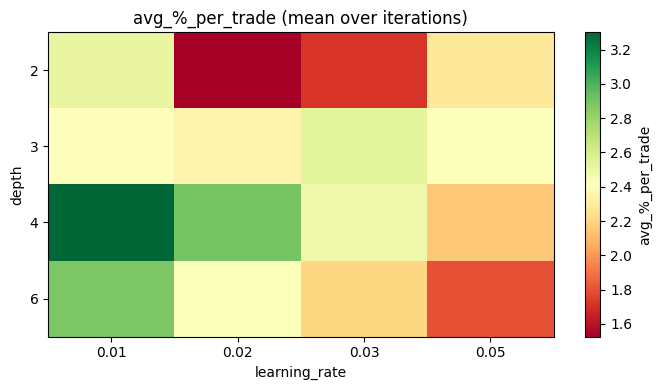

Топ-5 по avg_%_per_trade:
 iterations  depth  learning_rate  auc_test      net_%  trades  avg_%_per_trade
        300      4           0.01  0.687211  35.333120       9         3.925902
        200      4           0.02  0.694861 197.315131      54         3.653984
        200      6           0.01  0.692425  98.468887      27         3.646996
        300      3           0.02  0.694110 216.761061      61         3.553460
        500      4           0.01  0.697937 300.921551      92         3.270886


In [18]:
import matplotlib.pyplot as plt

# Heatmap: depth x learning_rate (средний avg/trade)
pivot = df1.pivot_table(values='avg_%_per_trade', index='depth', columns='learning_rate', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('learning_rate')
ax.set_ylabel('depth')
plt.colorbar(im, ax=ax, label='avg_%_per_trade')
ax.set_title('avg_%_per_trade (mean over iterations)')
plt.tight_layout()
plt.show()

print('Топ-5 по avg_%_per_trade:')
print(df1.head(5)[['iterations', 'depth', 'learning_rate', 'auc_test', 'net_%', 'trades', 'avg_%_per_trade']].to_string(index=False))

## 7b. Сопоставимые по количеству сделок, выше по точности

Фильтр: trades ≥ 400 (как у NB16 768), avg_%_per_trade > 1.92% (baseline). Кто даёт стабильный объём сделок и при этом выше avg/trade?

In [19]:
NB16_TRADES = 768
NB16_AVG = 1.92
min_trades = 400  # сопоставимо с 768

comparable = df1[(df1['trades'] >= min_trades) & (df1['avg_%_per_trade'] > NB16_AVG)].copy()
comparable = comparable.sort_values('avg_%_per_trade', ascending=False).reset_index(drop=True)

print(f'NB16: trades={NB16_TRADES}, avg/trade={NB16_AVG}%')
print(f'Фильтр: trades>={min_trades}, avg/trade>{NB16_AVG}%')
print(f'\nКонфиги с сопоставимым числом сделок и выше avg/trade:')
if len(comparable) == 0:
    print('  Нет. Ослабляем: trades>=300')
    comparable = df1[(df1['trades'] >= 300) & (df1['avg_%_per_trade'] > NB16_AVG)].copy()
    comparable = comparable.sort_values('avg_%_per_trade', ascending=False).reset_index(drop=True)
print(comparable[['iterations', 'depth', 'learning_rate', 'auc_test', 'net_%', 'trades', 'avg_%_per_trade']].to_string(index=False))

NB16: trades=768, avg/trade=1.92%
Фильтр: trades>=400, avg/trade>1.92%

Конфиги с сопоставимым числом сделок и выше avg/trade:
 iterations  depth  learning_rate  auc_test       net_%  trades  avg_%_per_trade
        500      4           0.03  0.717093 1179.278579     451         2.614808
       1000      6           0.01  0.715835 1256.864679     491         2.559806
       1000      3           0.02  0.713511 1080.230021     428         2.523902
        500      6           0.02  0.716585 1238.327361     491         2.522052
        200      6           0.05  0.712801 1340.089595     546         2.454377
        300      6           0.03  0.713877 1105.907085     453         2.441296
        500      3           0.05  0.715322 1211.377903     514         2.356766
        300      4           0.05  0.715177 1073.330211     469         2.288551
       1000      4           0.02  0.716788 1339.456960     587         2.281869
       1000      2           0.05  0.716681 1118.577916     492

## 8. Рекомендация для NB16

**Прод:** **1000/4/0.02** — лучшая устойчивость (min по дням 2.00%, нет провалов), 587 сделок, avg 2.28%, net 1339%.

```python
model = cb.CatBoostClassifier(iterations=1000, depth=4, learning_rate=0.02, random_seed=42, verbose=0)
```

In [20]:
print('=== Итоговая рекомендация ===')
print('Прод: 1000/4/0.02 (устойчивость по дням, min avg 2.00%)')
print('model = cb.CatBoostClassifier(iterations=1000, depth=4, learning_rate=0.02, random_seed=42, verbose=0)')

=== Итоговая рекомендация ===
Best params: {'iterations': 300, 'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'min_data_in_leaf': 20}
avg_%_per_trade (test): 3.9259%

См. 05_experiments/23_CatBoost_Hyperparam_Tuning.ipynb — обновить NB16 по результатам.


## 9. Выводы

### Почему avg/trade выше, а net_% ниже?

`net_% = avg_%_per_trade × trades`. Селективная модель торгует реже, каждая сделка лучше, но меньше сделок → суммарный PnL ниже.

### Устойчивость: min по дням (худший день)

| Конфиг | val | test1 | test2 | **min** | trades |
|--------|-----|-------|-------|--------|--------|
| **1000/4/0.02** | 1.84% | 2.32% | 2.00% | **1.84%** | 587 |
| 200/6/0.05 | 1.45% | 2.43% | 2.32% | 1.45% | 546 |
| NB16 (300/6/0.05) | 1.78% | 2.02% | 1.57% | 1.57% | 768 |
| NB23 best | 0.92% | 2.56% | 6.67% | 0.92% | 9 |

**1000/4/0.02** — highest min (2.00%): нет провала ни на один день. 200/6/0.05 проседает на val (1.45%), NB16 — на test2 (1.57%).

### Общие выводы по тюнингу

1. **Зона оптимума:** depth 4–6, lr 0.02–0.05.
2. **1000/4/0.02** — выбор для прода: 587 сделок, avg 2.28%, net 1339%, устойчивость по дням (min 1.84%).
3. NB16 (300/6/0.05) — максимум net_% (1476%) и trades (768), но худший день 1.57%.
4. NB23 best (300/4/0.01) — 9 сделок, ненадёжно.

### Рекомендация

**Прод:** 1000/4/0.02 — лучший компромисс устойчивости и avg/trade.